In [7]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.simplefilter('ignore')

In [8]:
import kagglehub

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

# print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [9]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [10]:
df=pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

In [11]:
# drop dulpclicates
df[df.duplicated()]

,review,sentiment
3537,Quite what the producers of this appalling ada...,negative
3769,My favourite police series of all time turns t...,positive
4391,"Beautiful film, pure Cassavetes style. Gena Ro...",positive
6352,If you liked the Grinch movie... go watch that...,negative
6479,I want very much to believe that the above quo...,negative
...,...,...
49912,This is an incredible piece of drama and power...,positive
49950,This was a very brief episode that appeared in...,negative
49984,Hello it is I Derrick Cannon and I welcome you...,negative
49986,This movie is a disgrace to the Major League F...,negative


In [12]:
df=df.drop_duplicates()

In [13]:
df.head(3)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [14]:
# cleaning
# lower case
df['review']=df['review'].str.lower()

In [15]:
df.head(3)

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive


In [16]:
# remove whitespaces
df['review']=df['review'].str.strip()

In [17]:
df.head(3)

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive


In [18]:
# use short dataset
df=df[:10000]

In [19]:
# remove html tags
# first way
import re
def remove_tags(data):
    data=re.sub(r'<.*?>','',data)
    return data

In [20]:
df['review']=df['review'].apply(remove_tags)

In [21]:
# remove html tags
# second way not working
# df['review'].str.replace(r'<.*?>','')

In [22]:
def remove_url(data):
    data=re.sub(r"https?://\S+|www\.\S+",'',data)
    return data

In [23]:
df['review']=df['review'].apply(remove_url)

In [24]:
# code to check if a review contains an URL
df[df['review'].str.contains(r"https?://\S+|www\.\S+")].shape

(0, 2)

In [25]:
# expanding abbvr
# expand

In [26]:
def remove_abb(data):
    data = re.sub(r"he's", "he is", data)
    data = re.sub(r"there's", "there is", data)
    data = re.sub(r"We're", "We are", data)
    data = re.sub(r"That's", "That is", data)
    data = re.sub(r"won't", "will not", data)
    data = re.sub(r"they're", "they are", data)
    data = re.sub(r"Can't", "Cannot", data)
    data = re.sub(r"wasn't", "was not", data)
    data = re.sub(r"don\x89Ûªt", "do not", data)
    data= re.sub(r"aren't", "are not", data)
    data = re.sub(r"isn't", "is not", data)
    data = re.sub(r"What's", "What is", data)
    data = re.sub(r"haven't", "have not", data)
    data = re.sub(r"hasn't", "has not", data)
    data = re.sub(r"There's", "There is", data)
    data = re.sub(r"He's", "He is", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"You're", "You are", data)
    data = re.sub(r"I'M", "I am", data)
    data = re.sub(r"shouldn't", "should not", data)
    data = re.sub(r"wouldn't", "would not", data)
    data = re.sub(r"i'm", "I am", data)
    data = re.sub(r"I\x89Ûªm", "I am", data)
    data = re.sub(r"I'm", "I am", data)
    data = re.sub(r"Isn't", "is not", data)
    data = re.sub(r"Here's", "Here is", data)
    data = re.sub(r"you've", "you have", data)
    data = re.sub(r"you\x89Ûªve", "you have", data)
    data = re.sub(r"we're", "we are", data)
    data = re.sub(r"what's", "what is", data)
    data = re.sub(r"couldn't", "could not", data)
    data = re.sub(r"we've", "we have", data)
    data = re.sub(r"it\x89Ûªs", "it is", data)
    data = re.sub(r"doesn\x89Ûªt", "does not", data)
    data = re.sub(r"It\x89Ûªs", "It is", data)
    data = re.sub(r"Here\x89Ûªs", "Here is", data)
    data = re.sub(r"who's", "who is", data)
    data = re.sub(r"I\x89Ûªve", "I have", data)
    data = re.sub(r"y'all", "you all", data)
    data = re.sub(r"can\x89Ûªt", "cannot", data)
    data = re.sub(r"would've", "would have", data)
    data = re.sub(r"it'll", "it will", data)
    data = re.sub(r"we'll", "we will", data)
    data = re.sub(r"wouldn\x89Ûªt", "would not", data)
    data = re.sub(r"We've", "We have", data)
    data = re.sub(r"he'll", "he will", data)
    data = re.sub(r"Y'all", "You all", data)
    data = re.sub(r"Weren't", "Were not", data)
    data = re.sub(r"Didn't", "Did not", data)
    data = re.sub(r"they'll", "they will", data)
    data = re.sub(r"they'd", "they would", data)
    data = re.sub(r"DON'T", "DO NOT", data)
    data = re.sub(r"That\x89Ûªs", "That is", data)
    data = re.sub(r"they've", "they have", data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"should've", "should have", data)
    data = re.sub(r"You\x89Ûªre", "You are", data)
    data = re.sub(r"where's", "where is", data)
    data = re.sub(r"Don\x89Ûªt", "Do not", data)
    data = re.sub(r"we'd", "we would", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"weren't", "were not", data)
    data = re.sub(r"They're", "They are", data)
    data = re.sub(r"Can\x89Ûªt", "Cannot", data)
    data = re.sub(r"you\x89Ûªll", "you will", data)
    data = re.sub(r"I\x89Ûªd", "I would", data)
    data = re.sub(r"let's", "let us", data)
    data = re.sub(r"it's", "it is", data)
    data = re.sub(r"can't", "cannot", data)
    data = re.sub(r"don't", "do not", data)
    data = re.sub(r"you're", "you are", data)
    data = re.sub(r"i've", "I have", data)
    data = re.sub(r"that's", "that is", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"doesn't", "does not",data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"didn't", "did not", data)
    data = re.sub(r"ain't", "am not", data)
    data = re.sub(r"you'll", "you will", data)
    data = re.sub(r"I've", "I have", data)
    data = re.sub(r"Don't", "do not", data)
    data = re.sub(r"I'll", "I will", data)
    data = re.sub(r"I'd", "I would", data)
    data = re.sub(r"Let's", "Let us", data)
    data = re.sub(r"you'd", "You would", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"Ain't", "am not", data)
    data = re.sub(r"Haven't", "Have not", data)
    data = re.sub(r"Could've", "Could have", data)
    data = re.sub(r"youve", "you have", data)
    data = re.sub(r"donå«t", "do not", data)
    data = re.sub(r"who'll", "who will", data)  # ye wala maine kiya hai
    return data


In [27]:
df['review']=df['review'].apply(remove_abb)

In [28]:
df.head().iloc[0].values

array(['one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other

In [29]:
# spelling_correction

In [30]:
from textblob import TextBlob as tb
# kar 90% accurate hai lagta hai mujhe

In [31]:
df2=df.head(3)
tb('how can i manag ths situatin').correct().string

'how can i manage the situation'

In [32]:
def spelling_correction(text):
    return tb(text).correct().string

In [33]:
df2['review'].apply(spelling_correction)

,review
0,one of the other reviews has mentioned that af...
1,a wonderful little production. the filling tec...
2,i thought this was a wonderful way to spend ti...


In [34]:
# remove string panctuations

In [35]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [36]:
def remove_punctuation(text):
    for i in string.punctuation:
        if i in text:
           text=text.replace(i,"")
    return text

In [37]:
df['review']=df['review'].apply(remove_punctuation)

In [38]:
# remove special character
# '[^\W\S]'
# df['review'].replace(['^\W\S'],"")

In [39]:
# [one, of, the, other, reviewers,]
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [40]:
from nltk.tokenize import word_tokenize

In [41]:
df['tokenized_review']=df['review'].apply(word_tokenize)

In [42]:
df.head()

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there is a family where a little boy...,negative,"[basically, there, is, a, family, where, a, li..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, in, the, time, of, mon..."


In [43]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [44]:
# stop word removal
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [45]:
def remove_stopwords(text):
    l=[]
    for word in text:
        if word not in stopwords.words('english'):
            l.append(word)

    return l


# remove_stopwords(['one', 'of', 'the', 'other', 'reviewers', 'has',])
df['tokenized_review']=df['tokenized_review'].apply(remove_stopwords)

In [46]:
df['review2']=df['tokenized_review'].apply(lambda x:" ".join(x))

In [47]:
df.head()

,review,sentiment,tokenized_review,review2
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",one reviewers mentioned watching 1 oz episode ...
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,...",basically family little boy jake thinks zombie...
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...


In [48]:
df['review_char_length']=df['review'].str.len()

In [49]:
df.head()

,review,sentiment,tokenized_review,review2,review_char_length
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",one reviewers mentioned watching 1 oz episode ...,1680
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn...",wonderful little production filming technique ...,936
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...,882
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,...",basically family little boy jake thinks zombie...,694
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...,1237


In [50]:
df['tokenized_review_words_length']=df['tokenized_review'].str.len()

In [51]:
df.head(3)

,review,sentiment,tokenized_review,review2,review_char_length,tokenized_review_words_length
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",one reviewers mentioned watching 1 oz episode ...,1680,164
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn...",wonderful little production filming technique ...,936,84
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...,882,87


In [52]:
import seaborn as sns

<Axes: xlabel='review_char_length', ylabel='Density'>

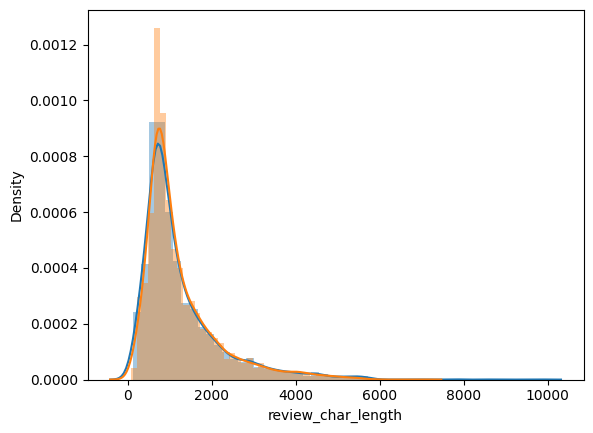

In [53]:
sns.distplot(df[df['sentiment']=='positive']['review_char_length'])
sns.distplot(df[df['sentiment']=='negative']['review_char_length'])

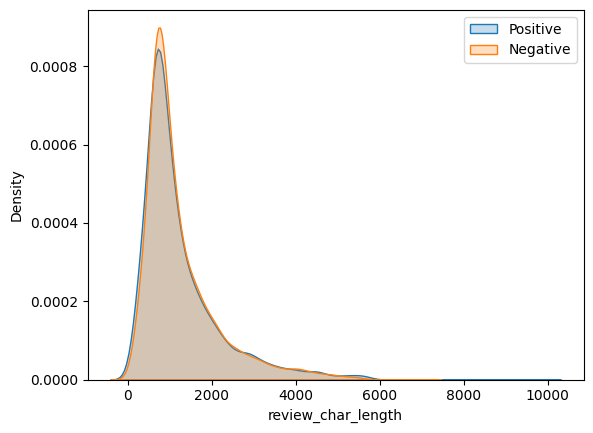

In [54]:
import matplotlib.pyplot as plt

sns.kdeplot(df[df['sentiment']=='positive']['review_char_length'], label='Positive', shade=True)
sns.kdeplot(df[df['sentiment']=='negative']['review_char_length'], label='Negative', shade=True)
plt.legend()
plt.show()

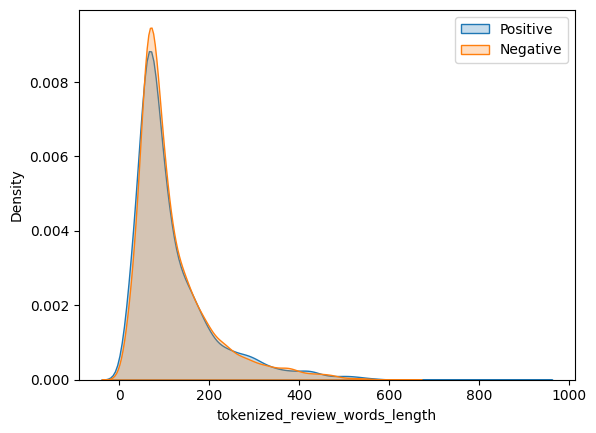

In [55]:
sns.kdeplot(df[df['sentiment']=='positive']['tokenized_review_words_length'], label='Positive', shade=True)
sns.kdeplot(df[df['sentiment']=='negative']['tokenized_review_words_length'], label='Negative', shade=True)
plt.legend()
plt.show()

In [56]:
su=df['tokenized_review'].sum()

In [57]:
su

['one',
 'reviewers',
 'mentioned',
 'watching',
 '1',
 'oz',
 'episode',
 'hooked',
 'right',
 'exactly',
 'happened',
 'methe',
 'first',
 'thing',
 'struck',
 'oz',
 'brutality',
 'unflinching',
 'scenes',
 'violence',
 'set',
 'right',
 'word',
 'go',
 'trust',
 'show',
 'faint',
 'hearted',
 'timid',
 'show',
 'pulls',
 'punches',
 'regards',
 'drugs',
 'sex',
 'violence',
 'hardcore',
 'classic',
 'use',
 'wordit',
 'called',
 'oz',
 'nickname',
 'given',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'focuses',
 'mainly',
 'emerald',
 'city',
 'experimental',
 'section',
 'prison',
 'cells',
 'glass',
 'fronts',
 'face',
 'inwards',
 'privacy',
 'high',
 'agenda',
 'em',
 'city',
 'home',
 'manyaryans',
 'muslims',
 'gangstas',
 'latinos',
 'christians',
 'italians',
 'irish',
 'moreso',
 'scuffles',
 'death',
 'stares',
 'dodgy',
 'dealings',
 'shady',
 'agreements',
 'never',
 'far',
 'awayi',
 'would',
 'say',
 'main',
 'appeal',
 'show',
 'due',
 'fact',
 'go

In [58]:
from nltk import ngrams
pd.Series(ngrams(df['tokenized_review'].sum(),2)).value_counts()

,count
"(I, would)",492
"(ever, seen)",459
"(special, effects)",438
"(I, seen)",429
"(even, though)",372
...,...
"(connection, original)",1
"(night, 1980)",1
"(1980, directed)",1
"(directed, bruce)",1


In [59]:
from nltk import ngrams

pd.Series(ngrams(df['tokenized_review'].sum(),3)).value_counts()

,count
"(I, ever, seen)",169
"(worst, movie, ever)",69
"(movie, ever, seen)",56
"(I, would, like)",56
"(one, worst, movies)",55
...,...
"(transfer, big, screen)",1
"(successfully, transfer, big)",1
"(print, successfully, transfer)",1
"(fine, print, successfully)",1


In [60]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

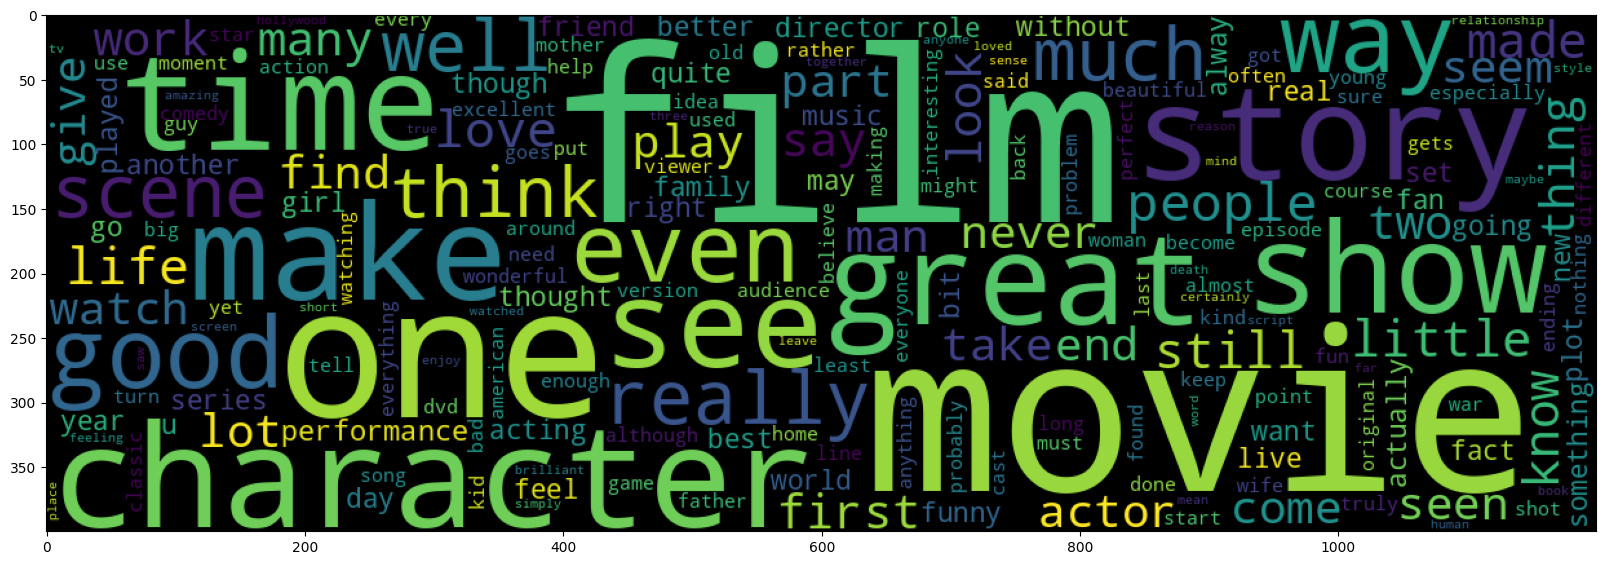

In [61]:
plt.figure(figsize = (20,20)) # Positive Review Text
wc = WordCloud(width = 1200, height = 400).generate(" ".join(df[df['sentiment'] == 'positive']['review2']))
plt.imshow(wc)

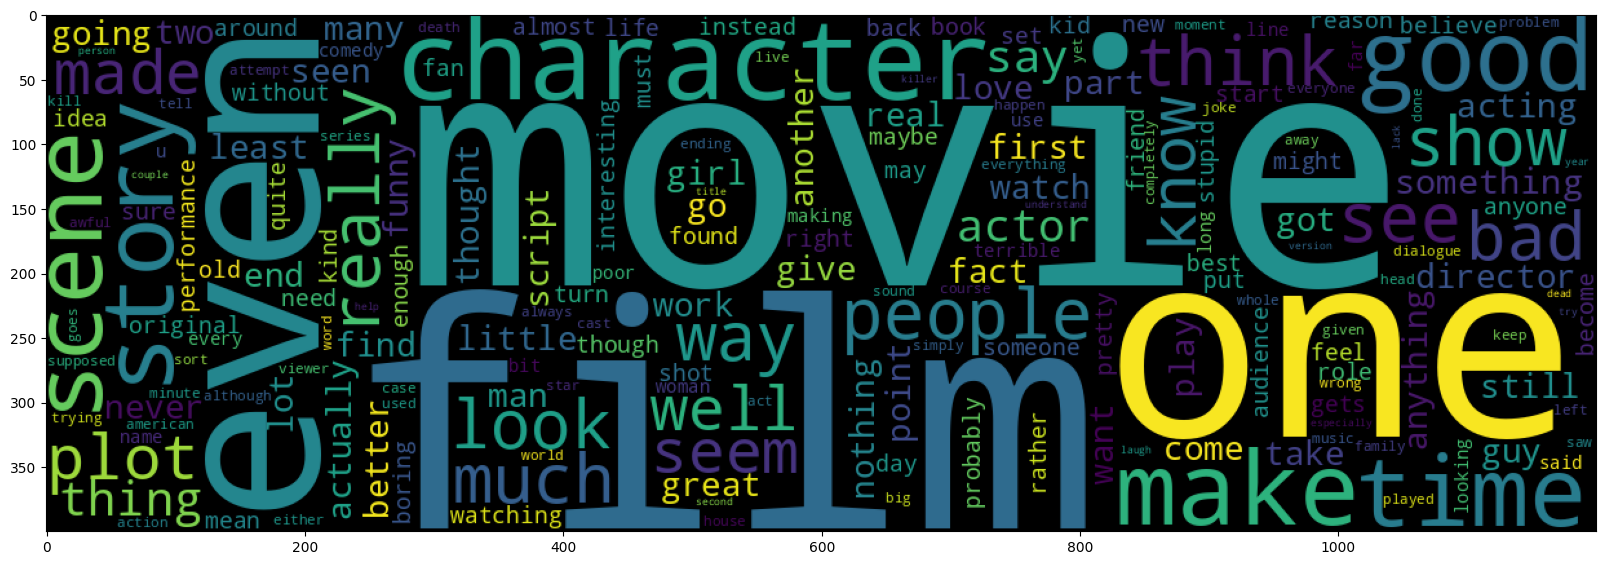

In [62]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize = (20,20)) # Positive Review Text
wc = WordCloud(width = 1200 , height = 400).generate(" ".join(df[df['sentiment'] == 'negative']['review2']))
plt.imshow(wc)

In [63]:
# BoW(beg of words)
from sklearn.feature_extraction.text import CountVectorizer

In [64]:
count_vectorizer = CountVectorizer(max_features=5000,ngram_range=(3,3))
bag_of_words = count_vectorizer.fit_transform(df['review'])
bag_of_words = pd.DataFrame(bag_of_words.toarray(),columns = count_vectorizer.get_feature_names_out())

In [65]:
count_vectorizer = CountVectorizer(max_features=4000,ngram_range=(1,3))
bag_of_words2 = count_vectorizer.fit_transform(df['review'])
bag_of_words2 = pd.DataFrame(bag_of_words2.toarray(),columns = count_vectorizer.get_feature_names_out())

In [72]:
count_vectorizer = CountVectorizer(max_features=3000,ngram_range=(2,2))
bag_of_words3 = count_vectorizer.fit_transform(df['review'])
bag_of_words3 = pd.DataFrame(bag_of_words3.toarray(),columns = count_vectorizer.get_feature_names_out())

In [73]:
bag_of_words3

,10 minutes,20 minutes,20 years,90 minutes,ability to,able to,about an,about as,about her,about his,...,you watch,you were,you will,you would,young and,young man,young woman,your life,your own,your time
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(bag_of_words.values)

In [77]:
pca_result

array([[ 0.58758248, -0.38968132],
       [ 0.49161013, -0.5198673 ],
       [-0.31732662, -0.13083407],
       ...,
       [-0.19499713,  0.08442515],
       [-0.23903103, -0.08642845],
       [ 0.12981121,  0.86349635]])

In [79]:
pca_result.shape

(10000, 2)

In [ ]:
# old version mai chalta hai ab nahi chalta
# sns.scatterplot(pca_result[:,0],pca_result[:,1],hue=df['sentiment'])

<Axes: >

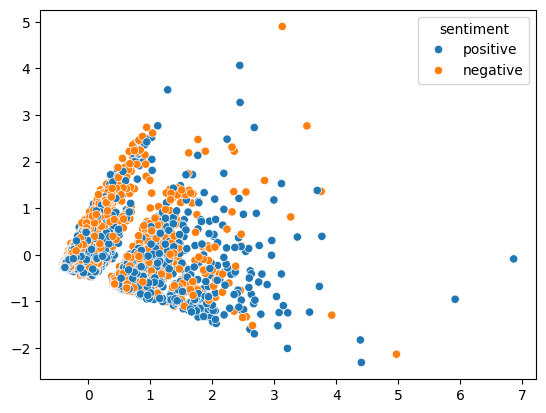

In [83]:
sns.scatterplot(x=pca_result[:, 0],y=pca_result[:, 1],hue=df["sentiment"])